In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
cereal_df = pd.read_csv('C:/Users/HELLO/Desktop/Data Science/data/cereal.csv')

In [4]:
cereal_df.head()

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100% Bran,N,C,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
1,100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505
3,All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912
4,Almond Delight,R,C,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843


In [15]:
fields = ['name', 'mfr','type','shelf', 'weight', 'cups', 'rating']
cereal_new_df = cereal_df.drop(fields, axis = 1)

In [16]:
cereal_new_df.head()

,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins
0,70,4,1,130,10.0,5.0,6,280,25
1,120,3,5,15,2.0,8.0,8,135,0
2,70,4,1,260,9.0,7.0,5,320,25
3,50,4,0,140,14.0,8.0,0,330,25
4,110,2,2,200,1.0,14.0,8,-1,25


In [19]:
cereal_corr = cereal_new_df.corr()

In [21]:
ones_corr = np.ones_like(cereal_corr, dtype = bool)
ones_corr

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True]])

In [22]:
mask = np.triu(ones_corr)
mask

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True],
       [False,  True,  True,  True,  True,  True,  True,  True,  True],
       [False, False,  True,  True,  True,  True,  True,  True,  True],
       [False, False, False,  True,  True,  True,  True,  True,  True],
       [False, False, False, False,  True,  True,  True,  True,  True],
       [False, False, False, False, False,  True,  True,  True,  True],
       [False, False, False, False, False, False,  True,  True,  True],
       [False, False, False, False, False, False, False,  True,  True],
       [False, False, False, False, False, False, False, False,  True]])

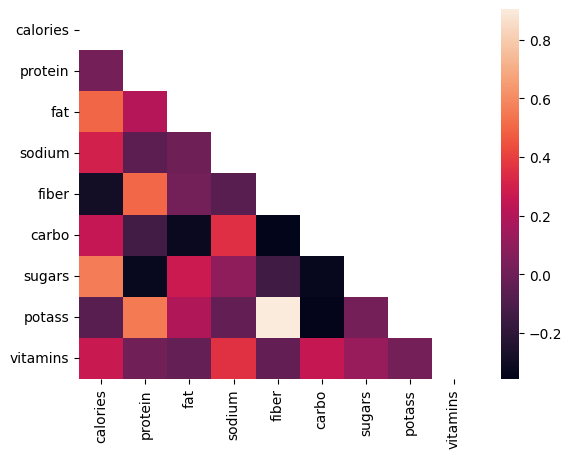

In [27]:
sns.heatmap(data = cereal_corr, mask = mask);

In [30]:
adjusted_mask = mask[1:, :-1]
adjusted_mask

array([[False,  True,  True,  True,  True,  True,  True,  True],
       [False, False,  True,  True,  True,  True,  True,  True],
       [False, False, False,  True,  True,  True,  True,  True],
       [False, False, False, False,  True,  True,  True,  True],
       [False, False, False, False, False,  True,  True,  True],
       [False, False, False, False, False, False,  True,  True],
       [False, False, False, False, False, False, False,  True],
       [False, False, False, False, False, False, False, False]])

In [31]:
adjusted_mask_corr = cereal_corr.iloc[1:, :-1]

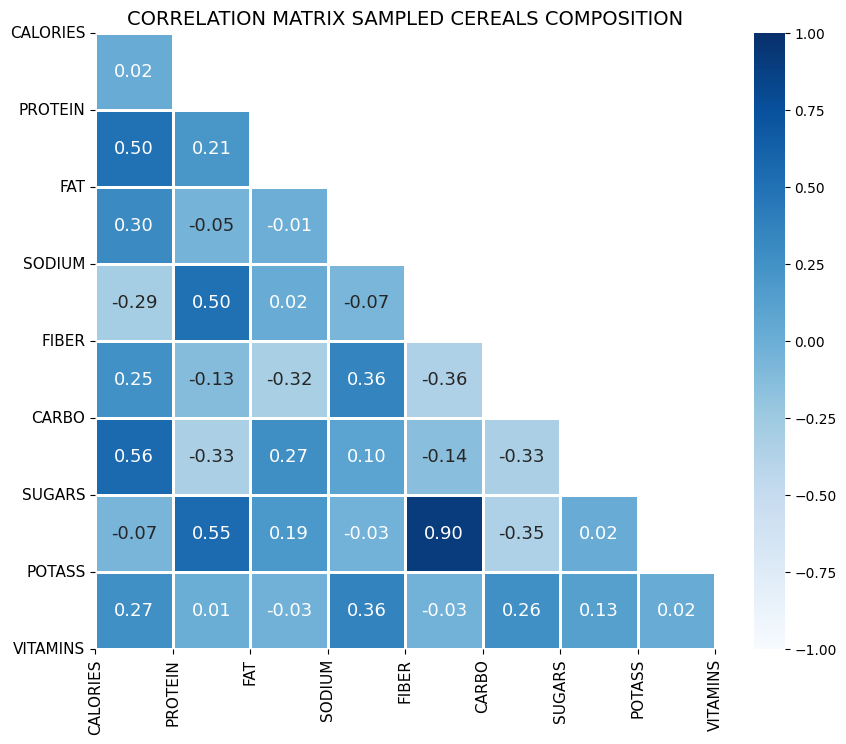

In [63]:
fig, ax = plt.subplots(figsize = (10,8));
sns.heatmap(data = adjusted_mask_corr, mask = adjusted_mask,
           annot = True, annot_kws = {'fontsize': 13}, fmt = '.2f', cmap = "Blues",
           vmin = -1, vmax = 1, linecolor = 'white', linewidth = 1);

yticks = [i.upper() for i in cereal_corr.index]
xticks = [i.upper() for i in cereal_corr.columns]

ax.set_yticks(range(len(yticks)));
ax.set_yticklabels(yticks, rotation = 0, fontsize = 11);

ax.set_xticks(range(len(xticks)));
ax.set_xticklabels(xticks, rotation = 90, fontsize = 11);

title = "CORRELATION MATRIX SAMPLED CEREALS COMPOSITION"
ax.set_title(title, loc = 'center', fontsize = 14);